# Análise Exploratória dos Dados

Este notebook tem como objetivo realizar uma análise exploratória do dataset ASSISTments, bucando compreender padrões de desempenho dos estudantes e identificar possíveis indicadores de dificuldade de aprendizado.

Link do Dataset: https://www.kaggle.com/datasets/nicolaswattiez/skillbuilder-data-2009-2010?resource=download

## Importação das Bibliotecas

Para que tudo ocorra de maneira correta, rode a célula abaixo para realizar a importação das bibliotecas:

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Carregamento dos Dados

Nesta etapa, os dados são carregados a partir de uma amostra do dataset original, permitindo análises mais eficientes sem comprometer a representatividade do conjunto de dados.

In [107]:
df = pd.read_csv("../dataset/sample.csv")
df.head()

,problem_log_id,skill,problem_id,user_id,assignment_id,assistment_id,start_time,end_time,problem_type,original,...,overlap_time,template_id,answer_id,answer_text,first_action,problemlogid,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
0,142256246,Conversion of Fraction Decimals Percents,85832,126240,649789,47314,2013-03-05 13:33:08,2013-03-05 13:33:23.517,algebra,1,...,15502,29869,NaN,13/100,0,142256246,0.361323,0.000000,0.766925,0.000000
1,145557895,NaN,437124,220219,539600,255713,2013-06-27 12:19:51,2013-06-27 12:20:06.231,choose_1,1,...,15169,255713,NaN,D. Wind speed,0,145557895,0.361323,0.000000,0.766925,0.000000
2,142795456,NaN,190212,179178,720861,99642,2013-03-26 12:02:41,2013-03-26 12:03:05.482,algebra,1,...,24471,99142,NaN,2/1,0,142795456,0.361323,0.000000,0.766925,0.697987
3,140415576,NaN,508123,182030,647492,303910,2012-12-19 13:50:02,2012-12-19 13:50:14.51,choose_1,1,...,12423,303910,NaN,inequality,0,140415576,0.361323,0.000000,0.766925,0.912281
4,138589431,Addition and Subtraction Positive Decimals,365958,155793,586953,204020,2012-10-22 11:45:23,2012-10-22 11:46:19.767,algebra,1,...,56748,204020,NaN,259.762,0,138589431,0.361323,0.984127,0.766925,0.762689


## Visão Geral dos Dados

A seguir, são apresentadas informações gerais sobre o dataset, incluindo número de registros, colunas e tipos de dados, auxiliando na compreensão do conjunto de dados antes de seguir para as análises.

In [108]:
df.info() # colunas presentes e tipo dos dados
df.describe() # resumo de medidas (count, mean, etc) de cada coluna

<class 'pandas.DataFrame'>
RangeIndex: 61233 entries, 0 to 61232
Data columns (total 35 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   problem_log_id                     61233 non-null  int64  
 1   skill                              26546 non-null  str    
 2   problem_id                         61233 non-null  int64  
 3   user_id                            61233 non-null  int64  
 4   assignment_id                      61233 non-null  int64  
 5   assistment_id                      61233 non-null  int64  
 6   start_time                         61233 non-null  str    
 7   end_time                           61233 non-null  str    
 8   problem_type                       61233 non-null  str    
 9   original                           61233 non-null  int64  
 10  correct                            61233 non-null  float64
 11  bottom_hint                        60660 non-null  float64
 12  h

,problem_log_id,problem_id,user_id,assignment_id,assistment_id,original,correct,bottom_hint,hint_count,attempt_count,...,school_id,overlap_time,template_id,answer_id,first_action,problemlogid,Average_confidence(FRUSTRATED),Average_confidence(CONFUSED),Average_confidence(CONCENTRATING),Average_confidence(BORED)
count,6.123300e+04,61233.000000,61233.000000,61233.000000,61233.000000,61233.000000,61233.000000,60660.000000,61233.000000,61233.000000,...,61230.000000,6.123300e+04,61233.000000,6.100000e+01,61233.000000,6.123300e+04,61233.000000,61233.000000,61233.000000,61233.000000
mean,1.414875e+08,367477.497983,177029.708474,677244.040027,219537.174710,0.949945,0.679258,0.121414,0.339294,1.340911,...,6926.025135,5.466085e+04,208175.710369,4.262232e+05,0.062515,1.414875e+08,0.389075,0.045014,0.682373,0.255444
std,2.691443e+06,219372.291216,31850.826327,94237.943238,139217.910342,0.218060,0.466556,0.326611,0.981895,1.071434,...,3328.413784,1.394567e+06,145827.040826,3.374638e+05,0.266005,2.691443e+06,0.101915,0.193019,0.171394,0.285797
min,1.368432e+08,14.000000,52535.000000,266574.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,-6.647000e+03,16.000000,3.942000e+03,0.000000,1.368432e+08,0.361323,0.000000,0.170732,0.000000
25%,1.391590e+08,127782.000000,172018.000000,586113.000000,68468.000000,1.000000,0.000000,0.000000,0.000000,1.000000,...,5255.000000,9.453000e+03,50299.000000,1.230500e+05,0.000000,1.391590e+08,0.361323,0.000000,0.766925,0.000000
50%,1.414934e+08,416806.000000,179167.000000,678588.000000,239900.000000,1.000000,1.000000,0.000000,0.000000,1.000000,...,5978.000000,2.251100e+04,239538.000000,3.187990e+05,0.000000,1.414934e+08,0.361323,0.000000,0.766925,0.200000
75%,1.438110e+08,563329.000000,197304.000000,767359.000000,345669.000000,1.000000,1.000000,0.000000,0.000000,1.000000,...,9446.000000,5.535700e+04,342763.000000,7.276460e+05,0.000000,1.438110e+08,0.361323,0.000000,0.766925,0.442968
max,1.461387e+08,767080.000000,228212.000000,833045.000000,492550.000000,1.000000,1.000000,1.000000,8.000000,28.000000,...,12421.000000,3.442803e+08,492550.000000,1.120981e+06,2.000000,1.461387e+08,0.867133,1.000000,0.766925,1.000000


## Análise individual de um aluno

A análise por aluno permite identificar padrões específicos de dificuldade, considerando múltiplos fatores além da taxa de erro.

Observa-se que alguns assuntos (skills) apresentam:
- alta taxa de erro
- elevado tempo de resposta
- maior número de tentativas
- maior uso de dicas

Essas características indicam dificuldades reais de aprendizagem e podem ser utilizadas como base para recomendações personalizadas.

### Seleciona Aluno

In [129]:
aluno_id = df["user_id"].iloc[0]

dados_aluno = df[df["user_id"] == aluno_id] # Seleciona um aluno

### Taxa de Erro por Skill

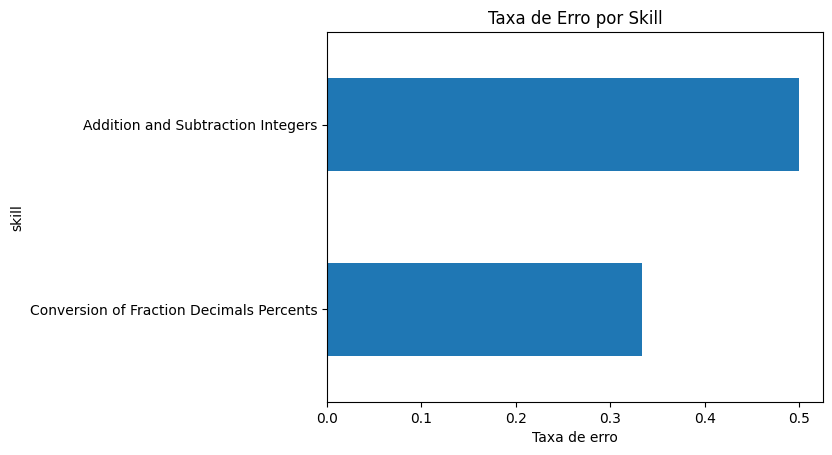

In [130]:
erro_por_skill = (  
    dados_aluno.assign(erro=(dados_aluno["correct"] == 0)) # cria uma nova coluna "erro": True/False
    .groupby("skill")["erro"] # agrupa por skill
    .mean() # média de True/False (taxa de erro)
    .sort_values(ascending=True) # ordena maior taxa para menor
)

# Gráfico
erro_por_skill.head(10).plot(kind="barh")
plt.title("Taxa de Erro por Skill")
plt.xlabel("Taxa de erro")
plt.show()

### Tempo Médio de Resposta por Skill

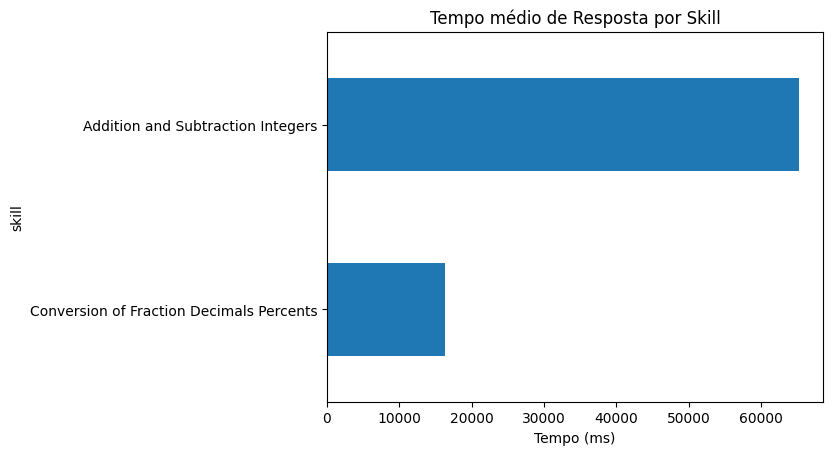

In [131]:
tempo_por_skill = (
    dados_aluno.groupby("skill")["ms_first_response"] # agrupa por skill e pega tempo de resposta
    .mean() # calcula o tempo médio por skill
    .sort_values(ascending=True) # ordena maior tempo para menor
)

# Gráfico
tempo_por_skill.head(10).plot(kind="barh")
plt.title("Tempo médio de Resposta por Skill")
plt.xlabel("Tempo (ms)")
plt.show()

### Tentativas Médias por skill

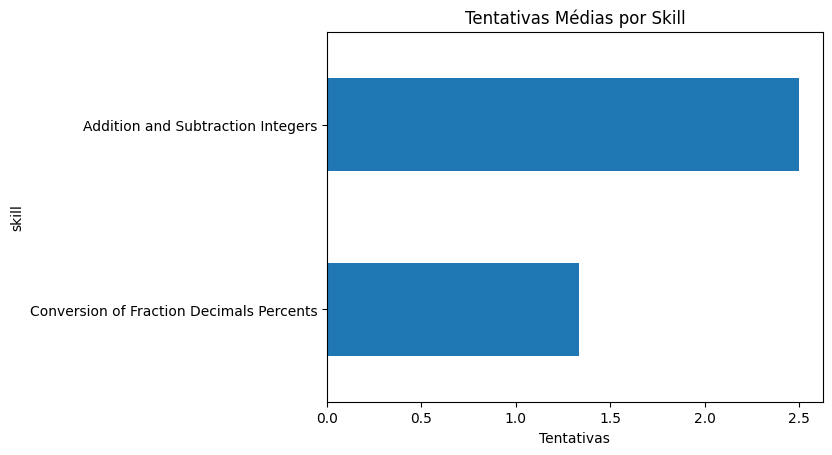

In [132]:
tentativas_por_skill = (
    dados_aluno.groupby("skill")["attempt_count"] # agrupa por skill
    .mean() # média de tentativas por skill
    .sort_values(ascending=True) # ordena
)

# Gráfico
tentativas_por_skill.head(10).plot(kind="barh")
plt.title("Tentativas Médias por Skill")
plt.xlabel("Tentativas")
plt.show()

### Média de Uso de Dicas por Skill

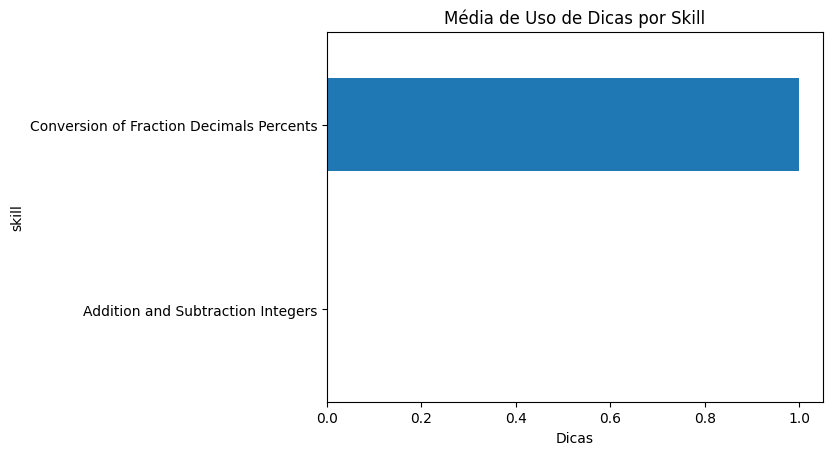

In [133]:
dicas_por_skill = (
    dados_aluno.groupby("skill")["hint_count"] # agrupa por skill
    .mean() # média de dicas usadas
    .sort_values(ascending=True) # ordena
)

dicas_por_skill.head(10).plot(kind="barh")
plt.title("Média de Uso de Dicas por Skill")
plt.xlabel("Dicas")
plt.show()

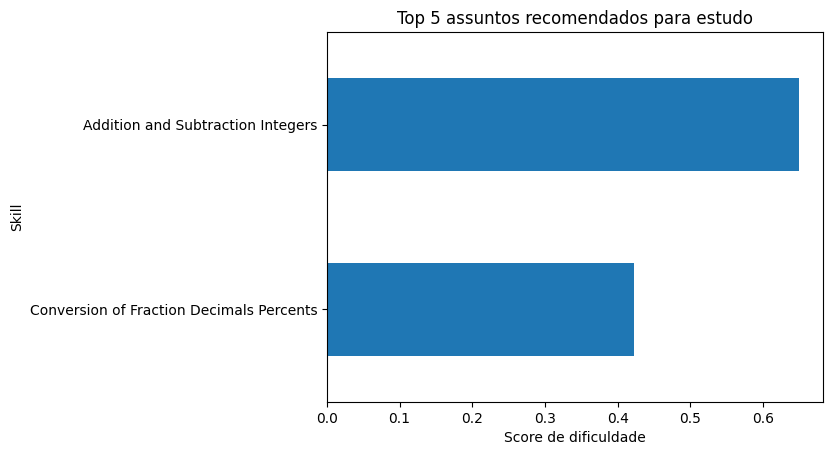

In [135]:
# Consolida métricas
tabela_metricas_aluno = pd.DataFrame({
    "taxa_erro": erro_por_skill,
    "tempo_medio": tempo_por_skill,
    "tentativas_medias": tentativas_por_skill,
    "dicas_medias": dicas_por_skill
})

# Cria score de dificuldade
tabela_metricas_aluno["score_dificuldade"] = (
    tabela_metricas_aluno["taxa_erro"] * 0.5 +
    (tabela_metricas_aluno["tentativas_medias"] / tabela_metricas_aluno["tentativas_medias"].max()) * 0.2 +
    (tabela_metricas_aluno["tempo_medio"] / tabela_metricas_aluno["tempo_medio"].max()) * 0.2 +
    (tabela_metricas_aluno["dicas_medias"] / tabela_metricas_aluno["dicas_medias"].max()) * 0.1
)

# Ranking final
ranking_recomendacao_aluno = tabela_metricas_aluno.sort_values(
    "score_dificuldade", ascending=True
)

# Gráfico final
top_recomendacoes = ranking_recomendacao_aluno.head(5)

top_recomendacoes["score_dificuldade"].plot(kind="barh")

plt.title("Top 5 assuntos recomendados para estudo")
plt.xlabel("Score de dificuldade")
plt.ylabel("Skill")

plt.show()